In [28]:
import scanpy as sc


brca_cell_adata = sc.read_h5ad("/data1/r20user3/shared_project/Hist2Cell/code/data_preprocessing/brca_cellabundance/brca_cellabundance_estimation.h5ad")
brca_cell_adata

AnnData object with n_obs × n_vars = 880 × 13199
    obs: '_indices', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'mod'
    obsm: 'means_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf', 'stds_cell_abundance_w_sf'

In [29]:
brca_cell_label_df = brca_cell_adata.obsm['q05_cell_abundance_w_sf']
brca_cell_label_df.head(2)

,q05cell_abundance_w_sf_CD4-positive helper T cell,"q05cell_abundance_w_sf_CD4-positive, alpha-beta T cell","q05cell_abundance_w_sf_CD8-positive, alpha-beta memory T cell",q05cell_abundance_w_sf_IgA plasma cell,q05cell_abundance_w_sf_IgG plasma cell,q05cell_abundance_w_sf_T cell,"q05cell_abundance_w_sf_activated CD4-positive, alpha-beta T cell","q05cell_abundance_w_sf_activated CD8-positive, alpha-beta T cell",q05cell_abundance_w_sf_alternatively activated macrophage,q05cell_abundance_w_sf_basal cell,...,q05cell_abundance_w_sf_naive B cell,q05cell_abundance_w_sf_natural killer cell,q05cell_abundance_w_sf_neutrophil,q05cell_abundance_w_sf_non-classical monocyte,q05cell_abundance_w_sf_pericyte,q05cell_abundance_w_sf_plasmacytoid dendritic cell,q05cell_abundance_w_sf_regulatory T cell,q05cell_abundance_w_sf_unswitched memory B cell,q05cell_abundance_w_sf_vascular associated smooth muscle cell,q05cell_abundance_w_sf_vein endothelial cell
TCGA-A8-A09R-01Z-00-DX1,0.002925,0.002420,0.010768,0.0259,0.045246,0.222976,0.024620,0.336438,0.060828,2.076841,...,0.006568,0.022835,0.065895,0.043894,0.131588,0.041848,0.070641,0.003808,0.631248,0.011149
TCGA-E2-A1IE-01Z-00-DX1,0.000710,0.000151,0.000354,0.0040,0.001229,0.003494,0.000591,0.000251,0.048617,0.182926,...,0.000041,0.000068,0.000024,0.000088,0.058550,0.000005,0.000034,0.000007,0.632732,0.040799


In [30]:
import pandas as pd

cell_names = [cell[23:] for cell in list(pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/A1/cell_ratio.csv").columns)[1:]]

from glob import glob
tif_list = glob('/data1/r20user3/shared_project/Hist2Cell/data/brca/*')
tif_list.sort()
test_slides = list()
for tif in tif_list:
    tif_path = tif.split('/')[-1]
    test_slides.append(tif_path)
test_slides[:2]

['TCGA-3C-AALK-01Z-00-DX1', 'TCGA-4H-AAAK-01Z-00-DX1']

In [31]:
import joblib
from tqdm import tqdm


pred_id_mena_dict = dict()        
for case in tqdm(test_slides):
    # os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/cross_source", case))
    try:
        save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/brca/breast_cross_source_epoch100_lr1e-4_2hop_ensemble_Trans1layer_GNNoutput50_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
        pred_and_label = joblib.load(save_path)
        pred_id_mena_dict[case] = pred_and_label['cell_abundance_predictions'].mean(axis=0)
    except:
        continue

100%|██████████| 826/826 [00:00<00:00, 5043.82it/s]


In [32]:
len(pred_id_mena_dict)

585

In [33]:
pred_id_mena_dict.keys()

dict_keys(['TCGA-3C-AALK-01Z-00-DX1', 'TCGA-4H-AAAK-01Z-00-DX1', 'TCGA-5L-AAT1-01Z-00-DX1', 'TCGA-5T-A9QA-01Z-00-DX1', 'TCGA-A1-A0SK-01Z-00-DX1', 'TCGA-A2-A04N-01Z-00-DX1', 'TCGA-A2-A04P-01Z-00-DX1', 'TCGA-A2-A04R-01Z-00-DX1', 'TCGA-A2-A04T-01Z-00-DX1', 'TCGA-A2-A04U-01Z-00-DX1', 'TCGA-A2-A04W-01Z-00-DX1', 'TCGA-A2-A04X-01Z-00-DX1', 'TCGA-A2-A0CK-01Z-00-DX1', 'TCGA-A2-A0CM-01Z-00-DX1', 'TCGA-A2-A0CP-01Z-00-DX1', 'TCGA-A2-A0CQ-01Z-00-DX1', 'TCGA-A2-A0CR-01Z-00-DX1', 'TCGA-A2-A0CT-01Z-00-DX1', 'TCGA-A2-A0CU-01Z-00-DX1', 'TCGA-A2-A0CX-01Z-00-DX1', 'TCGA-A2-A0CY-01Z-00-DX1', 'TCGA-A2-A0CZ-01Z-00-DX1', 'TCGA-A2-A0D0-01Z-00-DX1', 'TCGA-A2-A0D4-01Z-00-DX1', 'TCGA-A2-A0EN-01Z-00-DX1', 'TCGA-A2-A0EO-01Z-00-DX1', 'TCGA-A2-A0EQ-01Z-00-DX1', 'TCGA-A2-A0ER-01Z-00-DX1', 'TCGA-A2-A0ET-01Z-00-DX1', 'TCGA-A2-A0EU-01Z-00-DX1', 'TCGA-A2-A0EV-01Z-00-DX1', 'TCGA-A2-A0EW-01Z-00-DX1', 'TCGA-A2-A0EY-01Z-00-DX1', 'TCGA-A2-A0ST-01Z-00-DX1', 'TCGA-A2-A0SU-01Z-00-DX1', 'TCGA-A2-A0SV-01Z-00-DX1', 'TCGA-A2-A0SW-01Z

In [34]:
pred_id_mena_dict['TCGA-3C-AALK-01Z-00-DX1'].shape

(39,)

In [35]:
import numpy as np

pred_df_list = []
for case in pred_id_mena_dict.keys():
    pred_df = pd.DataFrame(data=np.expand_dims(pred_id_mena_dict[case], axis=0), columns=cell_names, index=[case])
    pred_df_list.append(pred_df)

In [36]:
pred_all_case_df = pd.concat(pred_df_list, join='inner')
pred_all_case_df.head(2)

,CD4-positive helper T cell,"CD4-positive, alpha-beta T cell","CD8-positive, alpha-beta memory T cell",IgA plasma cell,IgG plasma cell,T cell,"activated CD4-positive, alpha-beta T cell","activated CD8-positive, alpha-beta T cell",alternatively activated macrophage,basal cell,...,naive B cell,natural killer cell,neutrophil,non-classical monocyte,pericyte,plasmacytoid dendritic cell,regulatory T cell,unswitched memory B cell,vascular associated smooth muscle cell,vein endothelial cell
TCGA-3C-AALK-01Z-00-DX1,0.160704,0.221731,0.105877,1.572897,1.550151,0.039653,0.158888,0.780631,0.042309,0.400047,...,0.13908,0.243357,0.274147,0.143055,0.099567,0.431812,0.253349,0.102376,0.796682,0.079286
TCGA-4H-AAAK-01Z-00-DX1,0.306479,0.564471,0.156112,0.888829,0.700434,-0.041915,0.277069,2.113774,0.079509,0.217030,...,0.26064,0.287138,0.191035,0.218524,0.158000,0.309171,0.649358,0.164299,0.600419,0.160729


In [37]:
label_idx_set = set(brca_cell_label_df.index)
pred_idx_set = set(pred_all_case_df.index)
selected_idx_set = label_idx_set.intersection(pred_idx_set)
len(selected_idx_set)

585

In [38]:
selected_idx_list = list(selected_idx_set)

In [39]:
seleted_label_df = brca_cell_label_df.loc[selected_idx_list, :]
seleted_label_df.head(2)

,q05cell_abundance_w_sf_CD4-positive helper T cell,"q05cell_abundance_w_sf_CD4-positive, alpha-beta T cell","q05cell_abundance_w_sf_CD8-positive, alpha-beta memory T cell",q05cell_abundance_w_sf_IgA plasma cell,q05cell_abundance_w_sf_IgG plasma cell,q05cell_abundance_w_sf_T cell,"q05cell_abundance_w_sf_activated CD4-positive, alpha-beta T cell","q05cell_abundance_w_sf_activated CD8-positive, alpha-beta T cell",q05cell_abundance_w_sf_alternatively activated macrophage,q05cell_abundance_w_sf_basal cell,...,q05cell_abundance_w_sf_naive B cell,q05cell_abundance_w_sf_natural killer cell,q05cell_abundance_w_sf_neutrophil,q05cell_abundance_w_sf_non-classical monocyte,q05cell_abundance_w_sf_pericyte,q05cell_abundance_w_sf_plasmacytoid dendritic cell,q05cell_abundance_w_sf_regulatory T cell,q05cell_abundance_w_sf_unswitched memory B cell,q05cell_abundance_w_sf_vascular associated smooth muscle cell,q05cell_abundance_w_sf_vein endothelial cell
TCGA-A2-A25B-01Z-00-DX1,0.021054,0.011622,0.032690,0.003283,0.571465,0.809959,0.028526,0.116251,0.585638,2.817131,...,0.002734,0.001050,0.147876,0.054089,0.497305,0.015590,0.060863,0.012839,1.304804,0.003877
TCGA-XX-A89A-01Z-00-DX1,0.088581,0.049402,0.000276,0.137411,0.018741,0.000254,0.392683,0.261539,0.737049,0.245191,...,0.014247,0.018754,0.301552,0.019167,0.200621,0.178315,0.114770,0.002953,0.463271,0.134446


In [40]:
seleted_pred_df = pred_all_case_df.loc[selected_idx_list, :]
seleted_pred_df.head(2)

,CD4-positive helper T cell,"CD4-positive, alpha-beta T cell","CD8-positive, alpha-beta memory T cell",IgA plasma cell,IgG plasma cell,T cell,"activated CD4-positive, alpha-beta T cell","activated CD8-positive, alpha-beta T cell",alternatively activated macrophage,basal cell,...,naive B cell,natural killer cell,neutrophil,non-classical monocyte,pericyte,plasmacytoid dendritic cell,regulatory T cell,unswitched memory B cell,vascular associated smooth muscle cell,vein endothelial cell
TCGA-A2-A25B-01Z-00-DX1,0.508703,0.971135,0.252588,0.372399,0.622788,0.126515,0.464536,3.403176,0.094452,0.187473,...,0.442548,0.408415,0.209573,0.299984,0.242307,0.319212,1.088902,0.299445,0.389394,0.227875
TCGA-XX-A89A-01Z-00-DX1,0.161297,0.259072,0.091605,1.406296,1.607111,0.016018,0.152965,1.157069,0.048517,0.215499,...,0.129861,0.282398,0.271686,0.186916,0.106931,0.474923,0.319734,0.082675,0.716736,0.128110


In [41]:
normalized_seleted_pred_df = seleted_pred_df.apply(lambda row: row / row.sum(), axis=1)
normalized_seleted_label_df = seleted_label_df.apply(lambda row: row / row.sum(), axis=1)

In [42]:
from scipy.stats import pearsonr

test_cell_pearson_list = list()
test_cell_abundance_pos_pearson_average = 0.0
test_cell_abundance_all_pearson_average = 0.0
test_cell_abundance_pos_pearson_count = 0
for i in range(39):
    r, p = pearsonr(normalized_seleted_pred_df.iloc[:, i], normalized_seleted_label_df.iloc[:, i])
    if r > 0.0:
        test_cell_abundance_pos_pearson_count = test_cell_abundance_pos_pearson_count + 1
        test_cell_abundance_pos_pearson_average = test_cell_abundance_pos_pearson_average + r
    if np.isnan(r):
        r = 0.0
    test_cell_abundance_all_pearson_average = test_cell_abundance_all_pearson_average + r
    test_cell_pearson_list.append(r)
if test_cell_abundance_pos_pearson_count >= 1:
    test_cell_abundance_pos_pearson_average /= test_cell_abundance_pos_pearson_count
else:
    test_cell_abundance_pos_pearson_average = 0.0
test_cell_abundance_all_pearson_average = test_cell_abundance_all_pearson_average / 39

In [43]:
test_cell_abundance_pos_pearson_count

26

In [44]:
test_cell_abundance_pos_pearson_average

0.1348952598093401

In [45]:
test_cell_abundance_all_pearson_average

0.06331109350616096

In [46]:
test_cell_pearson_dict = dict()
for i in range(39):
    test_cell_pearson_dict[cell_names[i]] = test_cell_pearson_list[i]
test_cell_pearson_dict

{'CD4-positive helper T cell': -0.11193095873046023,
 'CD4-positive, alpha-beta T cell': 0.053047132384393215,
 'CD8-positive, alpha-beta memory T cell': 0.049370378316229244,
 'IgA plasma cell': -0.01178454710246491,
 'IgG plasma cell': -0.06500919018861379,
 'T cell': -0.032194483258069735,
 'activated CD4-positive, alpha-beta T cell': 0.07470682508400257,
 'activated CD8-positive, alpha-beta T cell': 0.16412952682574677,
 'alternatively activated macrophage': -0.15978022742651368,
 'basal cell': 0.12044029161702147,
 'capillary endothelial cell': 0.05117196219013014,
 'class switched memory B cell': 0.05365789768666822,
 'classical monocyte': -0.01632176683118056,
 'conventional dendritic cell': -0.02720794407522988,
 'effector memory CD4-positive, alpha-beta T cell': 0.010711020621698871,
 'effector memory CD8-positive, alpha-beta T cell': 0.09303558957334804,
 'endothelial cell of artery': 0.21233654869951143,
 'endothelial cell of lymphatic vessel': 0.3246868277728669,
 'fibrobla

In [47]:
seleted_label_df_column_sum = seleted_label_df.sum(axis=0)
seleted_label_df_column_sum

q05cell_abundance_w_sf_CD4-positive helper T cell                           20.047012
q05cell_abundance_w_sf_CD4-positive, alpha-beta T cell                      67.553469
q05cell_abundance_w_sf_CD8-positive, alpha-beta memory T cell               11.088328
q05cell_abundance_w_sf_IgA plasma cell                                      50.805477
q05cell_abundance_w_sf_IgG plasma cell                                     161.472248
q05cell_abundance_w_sf_T cell                                               76.679234
q05cell_abundance_w_sf_activated CD4-positive, alpha-beta T cell           108.786262
q05cell_abundance_w_sf_activated CD8-positive, alpha-beta T cell           266.151534
q05cell_abundance_w_sf_alternatively activated macrophage                  151.026409
q05cell_abundance_w_sf_basal cell                                          803.686101
q05cell_abundance_w_sf_capillary endothelial cell                          150.439888
q05cell_abundance_w_sf_class switched memory B cell   

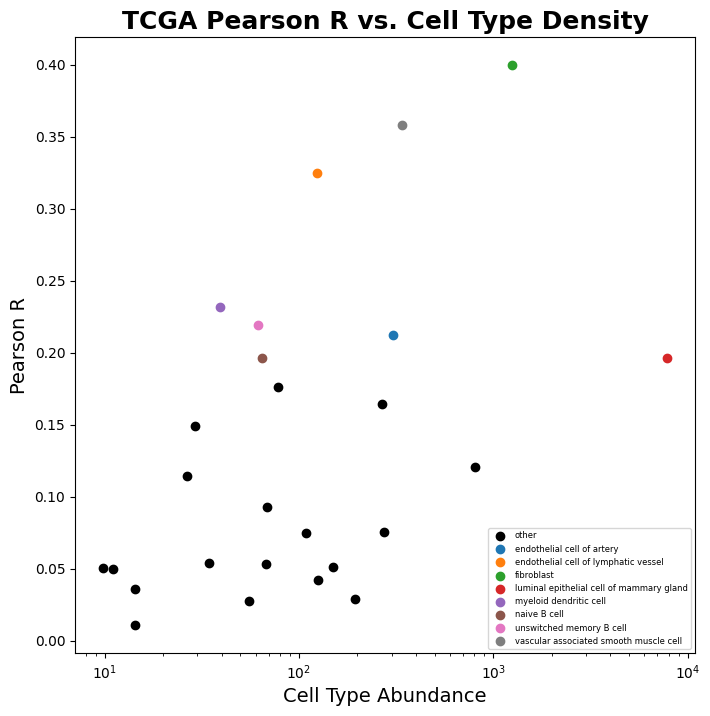

In [48]:
import matplotlib.pyplot as plt

density_list = seleted_label_df.sum(axis=0).tolist()
pearson_list = test_cell_pearson_list

# 过滤x轴大于2000的点
filtered_data = [(density, pearson, cell_name) for density, pearson, cell_name in zip(density_list, pearson_list, cell_names) if density < 10000 and pearson >= 0.]

# 将过滤后的数据分离为density和pearson两个列表
filtered_density_list, filtered_pearson_list, filterd_cell_name_list = zip(*filtered_data)

# Create a scatter plot
plt.figure(figsize=(8, 8))  # Set the figure size

# 使用过滤后的数据绘制散点图，并为每个点添加名称
other_label_added = False
for density, pearson, name in filtered_data:
    if pearson > 0.19:
        plt.scatter(x=density, y=pearson, label=name)
    else:
        if not other_label_added:
            plt.scatter(x=density, y=pearson, label="other", c="black")
            other_label_added = True
        else:
            plt.scatter(x=density, y=pearson, c="black")

# Set the title and axis labels
plt.title("TCGA Pearson R vs. Cell Type Density", fontsize=18, fontweight='bold')
plt.xlabel("Cell Type Abundance", fontsize=14)
plt.ylabel('Pearson R', fontsize=14)

# 设置X轴为对数坐标轴
plt.xscale('log')

# 显示图例
plt.legend(fontsize=6, loc='lower right')

# Show the plot
plt.show()

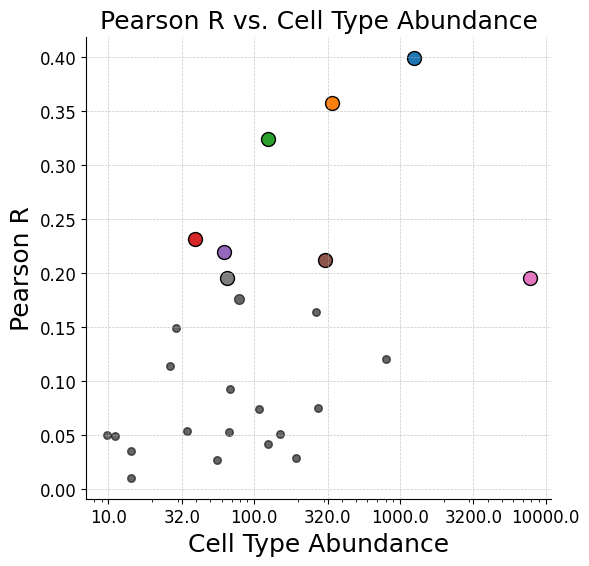

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# # Set the style to a white background with a grid
# sns.set_style("whitegrid")

# Filter the data to only include points with density less than 10,000 and Pearson coefficient greater than or equal to 0
filtered_data = [(density, pearson, cell_name) for density, pearson, cell_name in zip(density_list, pearson_list, cell_names) if density < 10000 and pearson >= 0.]

# Sort the filtered data by descending Pearson R values
filtered_data.sort(key=lambda x: x[1], reverse=True)

# Separate the filtered data into density and pearson lists
filtered_density_list, filtered_pearson_list, filtered_cell_name_list = zip(*filtered_data)

# Create a scatter plot
plt.figure(figsize=(6, 6))  # Set the figure size

label_list = []

# Use filtered data to draw the scatter plot, and add names for each point
other_label_added = False
for density, pearson, name in filtered_data:
    if pearson > 0.19:
        plt.scatter(x=density, y=pearson, label=name, s=100, edgecolor='black')
        label_list.append(name)
    else:
        if not other_label_added:
            plt.scatter(x=density, y=pearson, label="other", c="black", s=50, alpha=0.6, edgecolor='black')
            other_label_added = True
            label_list.append("other")
        else:
            plt.scatter(x=density, y=pearson, c="black", s=30, alpha=0.6, edgecolor='black')

# Set the title and axis labels
plt.title("Pearson R vs. Cell Type Abundance", fontsize=18)
plt.xlabel("Cell Type Abundance", fontsize=18)
plt.ylabel('Pearson R', fontsize=18)

# Set the X-axis to a logarithmic scale
plt.xscale('log')

# Customize the ticks and labels for better readability
# Define the xticks and their labels
xticks = [1e1, 3.2e1, 1e2, 3.2e2, 1e3, 3.2e3, 1e4]
xtick_labels = [str(x) for x in xticks]

# Customize the ticks and labels for better readability
plt.xticks(xticks, xtick_labels, fontsize=12)
plt.yticks(fontsize=12)

# Customize the grid and axis appearance
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Display the legend
# plt.legend(fontsize=10, loc='lower right', bbox_to_anchor=(1, 0.02))

# Set the color of x-axis and y-axis lines to black
ax = plt.gca()
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# Remove the top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# # Remove the top and right spines for a cleaner look
# sns.despine()

# Show the plot
plt.savefig("brca_PearsonR_vs_cellpair_density.svg", bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

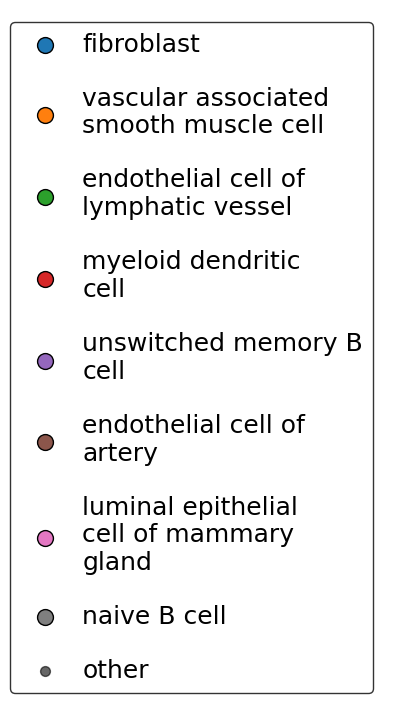

In [103]:
import textwrap

def wrap_labels(ax, width=40):
    """将图例标签换行的函数"""
    labels = [textwrap.fill(label.get_text(), width) for label in ax.get_legend().get_texts()]
    ax.legend(labels, loc="best", labelspacing=1.2, handletextpad=0.5, handlelength=2, fontsize=18, edgecolor='black')

# 然后创建并保存仅包含图例的图
fig_legend = plt.figure(figsize=(3, 5))
ax_legend = fig_legend.add_subplot(111)
# 使用同样的label和color创建一个空的散点图来生成图例
for label in label_list:
    if label == "other":
        ax_legend.scatter([], [], label=label, c="black", s=50, alpha=0.6, edgecolor='black')
        continue
    ax_legend.scatter([], [], label=label, s=130, edgecolor='black')
# 生成图例
ax_legend.legend(fontsize=18, loc='center')
ax_legend.axis('off')

# 调用wrap_labels函数
wrap_labels(ax_legend, width=20)  # 可以调整width以适合您的需求

# Show the plot
plt.savefig("brca_PearsonR_vs_cellpair_density_legend.svg", bbox_inches='tight', pad_inches=0)
plt.show()
plt.close(fig_legend)

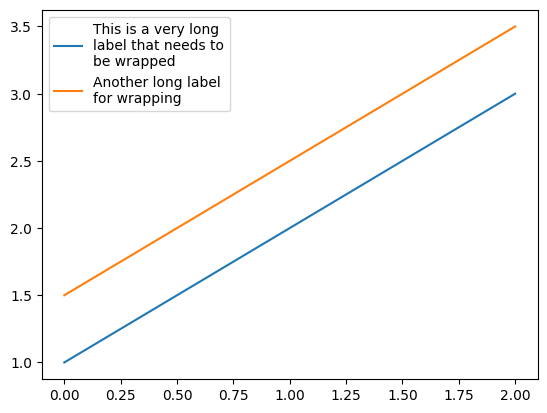

In [66]:
import matplotlib.pyplot as plt
import textwrap

def wrap_labels(ax, width=40):
    """将图例标签换行的函数"""
    labels = [textwrap.fill(label.get_text(), width) for label in ax.get_legend().get_texts()]
    ax.legend(labels, loc="best")

# 示例数据和绘图
fig, ax = plt.subplots()
ax.plot([1, 2, 3], label='This is a very long label that needs to be wrapped')
ax.plot([1.5, 2.5, 3.5], label='Another long label for wrapping')

# 创建图例
ax.legend()

# 调用wrap_labels函数
wrap_labels(ax, width=20)  # 可以调整width以适合您的需求

plt.show()